# PCA Ablation: Input Dimensionality vs Expert Performance

Sweep number of PCA components to control task difficulty.
PCA is fit on train split only to avoid leakage.

In [1]:
import sys
import os
from pathlib import Path

# Ensure CWD is liquid_jax/ so relative paths in Mnist resolve correctly
_liquid_jax = Path(__file__).resolve().parent.parent if "__file__" in dir() else Path(os.getcwd()).parent
os.chdir(_liquid_jax)
sys.path.insert(0, str(_liquid_jax))

from datetime import datetime
import yaml
import pandas as pd
import numpy as np
import jax
import jax.numpy as jnp
import tqdm
import matplotlib.pyplot as plt

from mnist_pca import make_pca_task
from liquid_solver import LEsolver, LEInfo
from learner_base import Learner
from structs import TrainParams
from train import train
from run_ablation_experiment import (
    LeMlpSkip, count_component_params, solve_head_hidden,
)

In [2]:
# Config
N_COMPONENTS_VALUES = [5, 10, 20, 50, 100, 200, 400, 784]
TOTAL_BUDGET = 50_000  # per-expert param budget
N_MODELS = 10
N_CLASSES = 10
BODY_OUT_DIM = 64
EPOCHS = 20
LR = 1e-3
BATCH_SIZE = 512
SEED = 42

In [3]:
solver = LEsolver(
    load_distribution_lambda=0.1,
    specialization_lambda=0,
)


def solve_pca_config(input_dim, total_budget, body_out_dim, n_classes, n_models):
    """Solve architecture given input_dim (= n_components). 
    
    Uses ~40% budget for body, ~30% each for heads.
    Body hidden is solved from its budget share.
    """
    body_budget = total_budget * 0.4
    head_budget = (total_budget - body_budget) / 2

    # Body: input_dim -> Dense(h_body) -> ReLU -> Dense(body_out_dim)
    h_body = max(1, round((body_budget - body_out_dim) / (input_dim + 1 + body_out_dim)))
    body_params = count_component_params(input_dim, h_body, body_out_dim)

    # Heads get the rest
    remaining = total_budget - body_params
    h_budget = remaining / 2
    h_out = solve_head_hidden(h_budget, body_out_dim, n_classes)
    h_del = solve_head_hidden(h_budget, body_out_dim, n_models)

    actual = (
        body_params
        + count_component_params(body_out_dim, h_out, n_classes)
        + count_component_params(body_out_dim, h_del, n_models)
    )

    return {
        "h_body": h_body,
        "h_out": h_out,
        "h_del": h_del,
        "body": (h_body, body_out_dim),
        "out": (h_out, n_classes),
        "delegation": (h_del, n_models),
        "actual_params": actual,
        "body_params": body_params,
        "input_dim": input_dim,
    }


def make_learner(n_models, body, out, delegation):
    class _Learner(Learner[LEInfo]):
        @staticmethod
        def get_model():
            return LeMlpSkip(
                n_models=n_models, body=body, out=out,
                delegation=delegation, skip=False,
            )

        @staticmethod
        def forward(key, x, model, params):
            ys, deleg = model.apply({"params": params}, x)
            leinfo = solver.solve_power(deleg)
            y = solver.mix_power_logits(ys, leinfo.power)
            return y, leinfo

        @staticmethod
        def auxillary_losses(key, train_return):
            return {
                "load_distribution_loss": solver.load_distribution_loss(train_return),
                "specialization_losss": solver.specialization_loss(train_return),
            }

    return _Learner

## Print configs to verify param distribution

In [4]:
configs = {}
for nc in N_COMPONENTS_VALUES:
    c = solve_pca_config(nc, TOTAL_BUDGET, BODY_OUT_DIM, N_CLASSES, N_MODELS)
    configs[nc] = c
    print(
        f"n_comp={nc:4d} | h_body={c['h_body']:4d} | h_out={c['h_out']:4d} | "
        f"h_del={c['h_del']:4d} | params={c['actual_params']:6d} / {TOTAL_BUDGET}"
    )

n_comp=   5 | h_body= 285 | h_out= 200 | h_del= 200 | params= 50034 / 50000
n_comp=  10 | h_body= 266 | h_out= 200 | h_del= 200 | params= 50034 / 50000
n_comp=  20 | h_body= 235 | h_out= 200 | h_del= 200 | params= 50059 / 50000
n_comp=  50 | h_body= 173 | h_out= 200 | h_del= 200 | params= 49979 / 50000
n_comp= 100 | h_body= 121 | h_out= 200 | h_del= 200 | params= 50049 / 50000
n_comp= 200 | h_body=  75 | h_out= 200 | h_del= 200 | params= 49959 / 50000
n_comp= 400 | h_body=  43 | h_out= 199 | h_del= 199 | params= 49929 / 50000
n_comp= 784 | h_body=  23 | h_out= 203 | h_del= 203 | params= 50061 / 50000


## Run the sweep

In [5]:
exp_dir = f"../experiments/pca_ablation/{datetime.now().strftime('%Y%m%d_%H%M%S')}"
os.makedirs(f"{exp_dir}/plots", exist_ok=True)

results = []
key = jax.random.key(SEED)

for nc in tqdm.tqdm(N_COMPONENTS_VALUES, desc="PCA sweep"):
    key, k_train = jax.random.split(key)
    c = configs[nc]

    # Create PCA task (fit on train, transform both)
    TaskCls, pca = make_pca_task(nc)
    print(f"\nn_components={nc}, explained_variance={pca.explained_variance_ratio_.sum():.4f}")

    learner_cls = make_learner(
        n_models=N_MODELS,
        body=c["body"],
        out=c["out"],
        delegation=c["delegation"],
    )

    # Verify param count
    model = learner_cls.get_model()
    dummy = jnp.zeros((1, nc))
    init_params = model.init(jax.random.key(0), dummy)["params"]
    per_expert = sum(p[0].size for p in jax.tree.leaves(init_params))
    expected = c["actual_params"]
    print(
        f"  expected={expected:6d} | actual={per_expert:6d} | "
        f"{'OK' if per_expert == expected else 'MISMATCH'}"
    )

    params = TrainParams(
        batch_size=BATCH_SIZE,
        preload_batches_to_gpu=5,
        valid_batches=2,
        epochs=EPOCHS,
        lr=LR,
        optimizer="adam",
        performance_loss="ce",
        task=TaskCls,
        learner=learner_cls,
    )

    metrics = train(k_train, params)

    result = {
        **c,
        "n_components": nc,
        "explained_variance": pca.explained_variance_ratio_.sum(),
        "final_val_loss": metrics["validation_loss"][-1],
        "final_train_loss": float(metrics["loss"][-1]),
        "best_val_loss": min(metrics["validation_loss"]),
        "best_val_ce_loss": min(metrics["validation_ce_loss"]),
        "best_val_accuracy": max(metrics.get("validation_accuracy", [0])),
        "final_val_accuracy": metrics.get("validation_accuracy", [0])[-1],
        "metrics": metrics,
    }
    results.append(result)

    # Save incrementally
    df = pd.DataFrame([{k: v for k, v in r.items() if k != "metrics"} for r in results])
    df.to_parquet(f"{exp_dir}/results.parquet")

print("\nDone!")

PCA sweep:   0%|          | 0/8 [00:00<?, ?it/s]


n_components=5, explained_variance=0.3323
  expected= 50034 | actual= 50034 | OK


E0327 09:14:32.775812 1237211 xtile_compiler.cc:399] Fusion: gemm_fusion_dot_general.38 = f32[10,512,64]{2,1,0} fusion(add.285, get-tuple-element.52), kind=kCustom, calls=gemm_fusion_dot_general.38_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"8","output_tiles":[{"sizes":["1","128","64"]}],"num_ctas":1,"num_stages":4,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0327 09:14:32.778630 1237211 xtile_compiler.cc:401] Computation: gemm_fusion_dot_general.38_computation.clone {
  parameter_0.1 = f32[512,10,285]{2,1,0} parameter(0)
  constant_765 = f32[] constant(0)
  broadcast.474 = f32[512,10,285]{2,1,0} broadcast(constant_765), dimensions={}
  max.53 = f32[512,10,285]{2,1,0} maximum(parameter_0.1, broadcast.474)
  parameter_1.1 = f32[10


n_components=10, explained_variance=0.4881
  expected= 50034 | actual= 50034 | OK


E0327 09:14:59.667488 1237209 xtile_compiler.cc:399] Fusion: gemm_fusion_dot_general.38 = f32[10,512,64]{2,1,0} fusion(add.285, get-tuple-element.52), kind=kCustom, calls=gemm_fusion_dot_general.38_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"8","output_tiles":[{"sizes":["1","128","64"]}],"num_ctas":1,"num_stages":4,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0327 09:14:59.667683 1237209 xtile_compiler.cc:401] Computation: gemm_fusion_dot_general.38_computation.clone {
  parameter_0.1 = f32[512,10,266]{2,1,0} parameter(0)
  constant_765 = f32[] constant(0)
  broadcast.474 = f32[512,10,266]{2,1,0} broadcast(constant_765), dimensions={}
  max.53 = f32[512,10,266]{2,1,0} maximum(parameter_0.1, broadcast.474)
  parameter_1.1 = f32[10

...


n_components=400, explained_variance=0.9958
  expected= 49929 | actual= 49929 | OK


E0327 09:16:53.725800 1237164 xtile_compiler.cc:399] Fusion: gemm_fusion_dot_general.45 = f32[10,512,64]{2,1,0} fusion(select_n.70, get-tuple-element.54), kind=kCustom, calls=gemm_fusion_dot_general.45_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"8","output_tiles":[{"sizes":["1","128","64"]}],"num_ctas":1,"num_stages":4,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0327 09:16:53.726181 1237164 xtile_compiler.cc:401] Computation: gemm_fusion_dot_general.45_computation.clone {
  parameter_0.6 = f32[10,512,199]{2,1,0} parameter(0)
  parameter_1.6 = f32[10,64,199]{2,1,0} parameter(1)
  ROOT dot_general.59 = f32[10,512,64]{2,1,0} dot(parameter_0.6, parameter_1.6), lhs_batch_dims={0}, lhs_contracting_dims={2}, rhs_batch_dims={0}, rhs_con


n_components=784, explained_variance=1.0000
  expected= 50061 | actual= 50061 | OK


E0327 09:17:19.241329 1237221 xtile_compiler.cc:399] Fusion: gemm_fusion_dot = f32[4,512,230]{2,1,0} fusion(bitcast.3, bitcast.2), kind=kCustom, calls=gemm_fusion_dot_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"8","output_tiles":[{"sizes":["1","128","256"]}],"num_ctas":1,"num_stages":4,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0327 09:17:19.241489 1237221 xtile_compiler.cc:401] Computation: gemm_fusion_dot_computation.clone {
  parameter_0 = f32[512,4,196]{2,1,0} parameter(0)
  parameter_1 = f32[4,196,230]{2,1,0} parameter(1)
  ROOT dot = f32[4,512,230]{2,1,0} dot(parameter_0, parameter_1), lhs_batch_dims={1}, lhs_contracting_dims={2}, rhs_batch_dims={0}, rhs_contracting_dims={1}, backend_config={"sizes":["32"]}
}
E0327 09:17:


Done!


## Plots

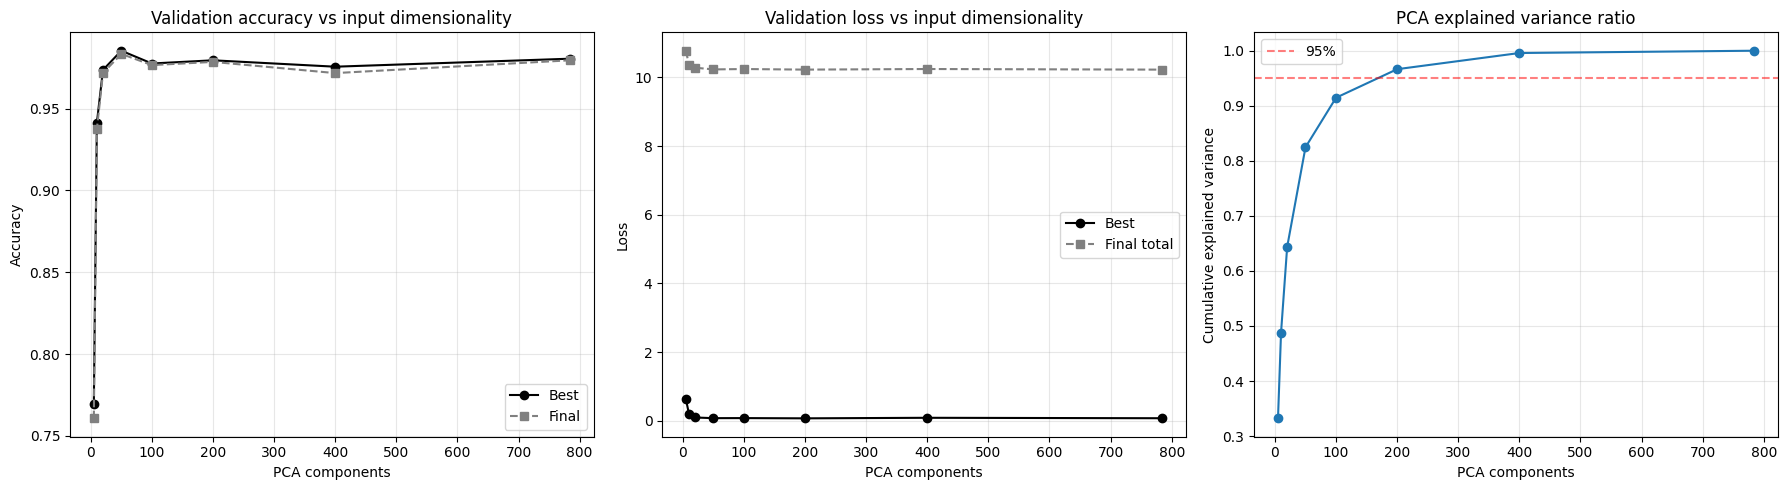

In [8]:
n_comp = [r["n_components"] for r in results]
exp_var = [r["explained_variance"] for r in results]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Accuracy vs n_components
ax = axes[0]
ax.plot(n_comp, [r["best_val_accuracy"] for r in results], "o-", color="black", label="Best")
ax.plot(n_comp, [r["final_val_accuracy"] for r in results], "s--", color="gray", label="Final")
ax.set_xlabel("PCA components")
ax.set_ylabel("Accuracy")
ax.set_title("Validation accuracy vs input dimensionality")
ax.legend()
ax.grid(True, alpha=0.3)

# CE loss vs n_components
ax = axes[1]
ax.plot(n_comp, [r["best_val_ce_loss"] for r in results], "o-", color="black", label="Best")
ax.plot(n_comp, [r["final_val_loss"] for r in results], "s--", color="gray", label="Final total")
ax.set_xlabel("PCA components")
ax.set_ylabel("Loss")
ax.set_title("Validation loss vs input dimensionality")
ax.legend()
ax.grid(True, alpha=0.3)

# Explained variance reference
ax = axes[2]
ax.plot(n_comp, exp_var, "o-", color="tab:blue")
ax.set_xlabel("PCA components")
ax.set_ylabel("Cumulative explained variance")
ax.set_title("PCA explained variance ratio")
ax.axhline(0.95, color="red", linestyle="--", alpha=0.5, label="95%")
ax.legend()
ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(f"{exp_dir}/plots/pca_summary.png", dpi=150)
plt.show()

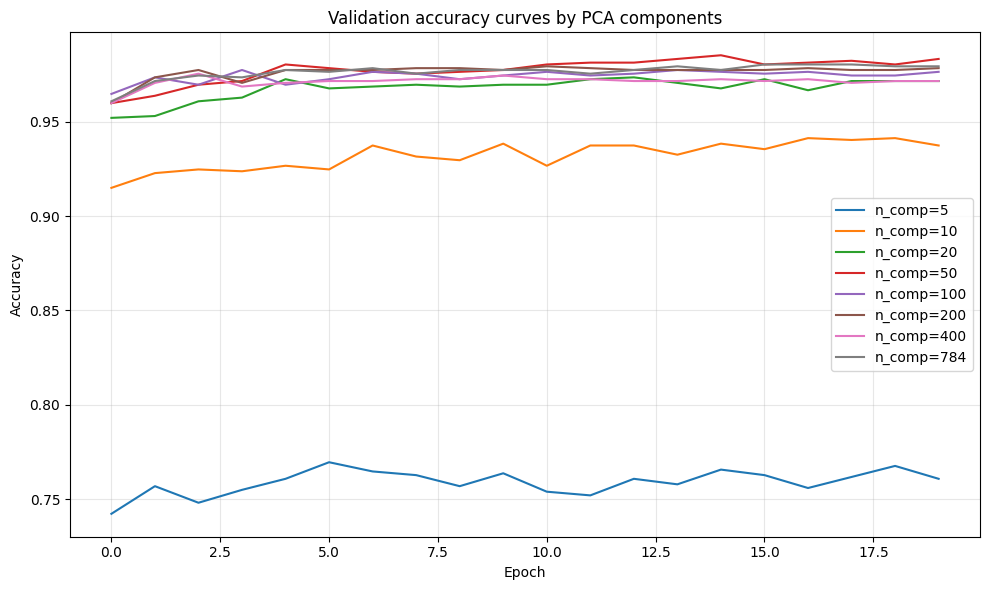

In [9]:
# Per-epoch accuracy curves colored by n_components
fig, ax = plt.subplots(figsize=(10, 6))
for r in results:
    acc = r["metrics"].get("validation_accuracy", [])
    if acc:
        ax.plot(acc, label=f"n_comp={r['n_components']}")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.set_title("Validation accuracy curves by PCA components")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(f"{exp_dir}/plots/accuracy_curves.png", dpi=150)
plt.show()